# F07: Hovmoller plots of rain rate and BT

1. Follow steps in Radar-processing/
2. Run this script to generate F07

# Preamble

In [63]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import sys
import metpy
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import metpy.calc as mpcalc
import pandas as pd
from netCDF4 import Dataset
import pyproj
import os
import glob
from datetime import datetime
import seaborn as sns
import netCDF4
from netCDF4 import Dataset
from metpy.units import units
import dask
import xarray as xr
from shapely import Polygon
import regionmask
import geopandas as gpd
import logging
import dask
from dask.distributed import Client
from dask import delayed
import functools
import zipfile
import tempfile
import wradlib as wrl
sys.path.append(os.path.join(r"/home/563/ac9768/GBR/scripts/Paper_figures")) 
# from define_wind_regimes import wind_times

In [64]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [65]:
barra_towns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_townsville.nc", engine="h5netcdf",chunks="auto")
barra_cairns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_cairns.nc", engine="h5netcdf",chunks="auto")
barra_willis = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_willis_island.nc", engine="h5netcdf",chunks="auto")

In [66]:
client = Client(n_workers=28,threads_per_worker=1,memory_limit=None,silence_logs=logging.ERROR,dashboard_address='8787') 
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39397 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/39397/status,
Dashboard: /proxy/39397/status,Workers: 28
Total threads: 28,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41433,Workers: 0
Dashboard: /proxy/39397/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35009,Total threads: 1
Dashboard: /proxy/36089/status,Memory: 0 B
Nanny: tcp://127.0.0.1:46827,


In [67]:
def utc_to_lst_shift(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    ds_lst = ds.assign_coords(time=ds.time + offset)
    return ds_lst

In [68]:
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw


# --- Usage ---
lon_towns  = (145.12054 + 147.9812)  / 2  # ≈ 146.55°E
lon_cairns = (144.27374 + 147.09222) / 2  # ≈ 145.68°E
lon_willis = (148.55927 + 151.36993) / 2

ne_towns,  se_towns,  sw_towns,  nw_towns  = wind_times(barra_towns,  lon_towns)
ne_cairns, se_cairns, sw_cairns, nw_cairns = wind_times(barra_cairns, lon_cairns)
ne_willis, se_willis, sw_willis, nw_willis = wind_times(barra_willis, lon_willis)

# Plot radar: load zarr files

In [7]:
BASE = '/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/Fig7_12LST_windregime_def'
sites   = ['cairns', 'willis']
regimes = ['nw', 'ne', 'se', 'sw']

# Build paths
radar_paths = {
    site: {regime: f"{BASE}/{site}_{regime}_hovmoller.zarr" for regime in regimes}
    for site in sites
}

lon_coords = {
    'cairns': xr.open_dataarray('/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/radar_anc/cairns_radar_lon.nc').values,
    'willis': xr.open_dataarray('/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/radar_anc/willis_radar_lon.nc').values,
}
lon_centers = {
    'cairns': (144.27374 + 147.09222) / 2,
    'willis': (148.55927 + 151.36993) / 2,
}

def open_hovmoller(path: str, lon_center: float, lon_x: np.ndarray) -> xr.DataArray:
    """Open hovmoller zarr, shift to LST, roll and double for 48h plotting."""
    offset_hours = round(lon_center * 4 / 60)
    ds = xr.open_zarr(path, chunks='auto')

    # Roll data AND coords together by the LST offset
    ds = ds.roll(hour=offset_hours, roll_coords=False)

    # Replace x coordinate with longitude values
    ds = ds.assign_coords(x=lon_x).rename({'x': 'lon'})

    return ds

# Open all zarr
results = {
    site: {
        regime: open_hovmoller(path, lon_centers[site], lon_coords[site])
        for regime, path in regime_dict.items()
        if os.path.exists(path)
    }
    for site, regime_dict in radar_paths.items()
}

/jobfs/168313098.gadi-pbs/ipykernel_532523/3112411068.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


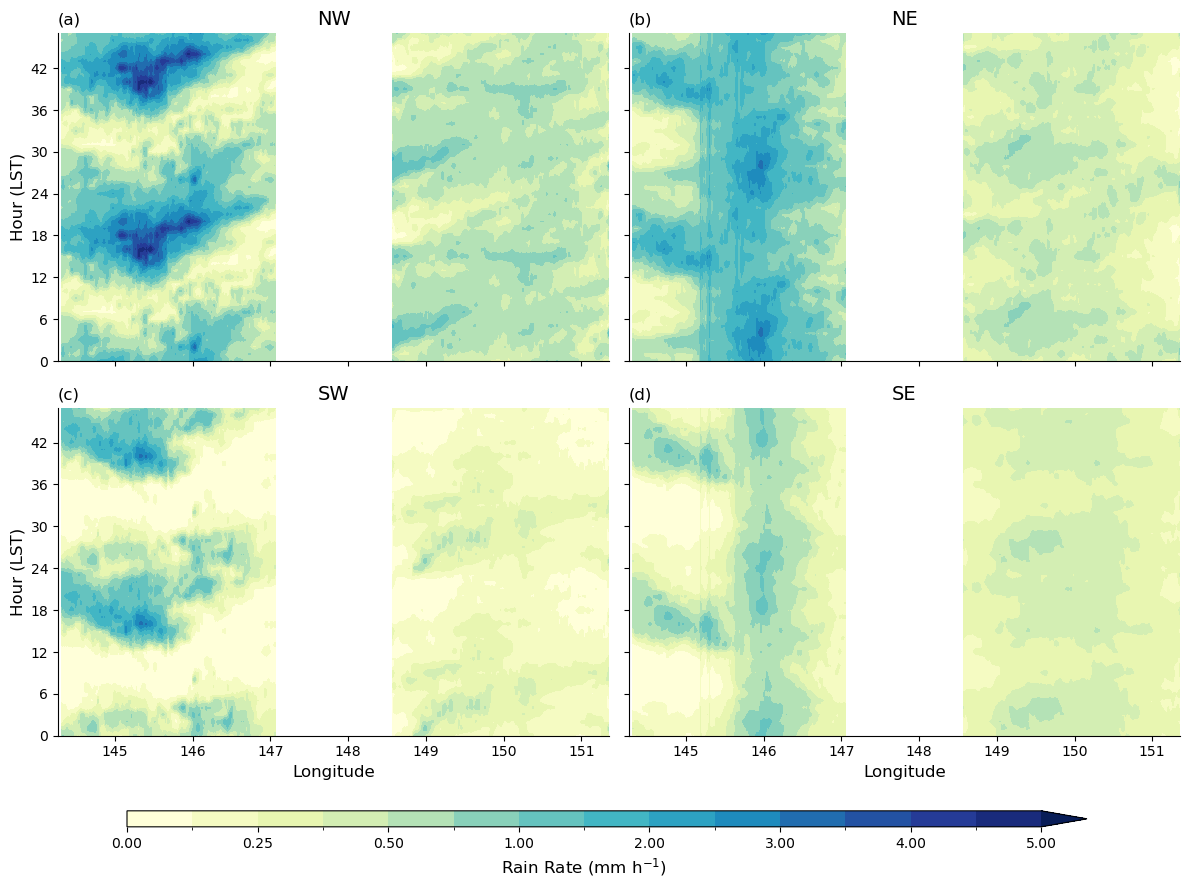

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True, sharex=True)
fig.patch.set_facecolor('white')

regimes   = ['nw', 'ne', 'sw', 'se']
titles    = {'nw': 'NW', 'ne': 'NE', 'sw': 'SW', 'se': 'SE'}
labels    = {'nw': '(a)', 'ne': '(b)', 'sw': '(c)', 'se': '(d)'}
levels_rr = [0, 0.125, 0.25, 0.375, 0.5, 0.75, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5,5]
cmap_rr   = 'YlGnBu'
norm_rr   = matplotlib.colors.BoundaryNorm(levels_rr, plt.cm.YlGnBu.N, extend='max')

for ax, regime in zip(axes.flat, regimes):
    # --- Cairns ---
    da_c = results['cairns'][regime].rainrate.compute()
    hours_48  = np.concatenate([da_c.hour.values, da_c.hour.values + 24])
    rain_48_c = np.concatenate([da_c.values, da_c.values], axis=0)
    im = ax.contourf(da_c.lon.values, hours_48, rain_48_c,
                     levels=levels_rr, cmap=cmap_rr, norm=norm_rr)

    # --- Willis ---
    da_w = results['willis'][regime].rainrate.compute()
    hours_48_w  = np.concatenate([da_w.hour.values, da_w.hour.values + 24])
    rain_48_w   = np.concatenate([da_w.values, da_w.values], axis=0)
    ax.contourf(da_w.lon.values, hours_48_w, rain_48_w,
                levels=levels_rr, cmap=cmap_rr, norm=norm_rr)

    # ax.axvline(145.9, color='black', linestyle='--', linewidth=0.8, alpha=0.7)  # Cairns radar
    # ax.axvline(149.5, color='grey',  linestyle='--', linewidth=0.8, alpha=0.7)  # Willis radar
    ax.set_title(titles[regime], fontsize=14)
    ax.set_title(labels[regime], loc='left', fontsize=12)
    ax.set_yticks(np.arange(0, 48, 6))
    ax.spines[['top', 'right']].set_visible(False)

axes[1, 0].set_xlabel('Longitude', fontsize=12)
axes[1, 1].set_xlabel('Longitude', fontsize=12)
axes[0, 0].set_ylabel('Hour (LST)', fontsize=12)
axes[1, 0].set_ylabel('Hour (LST)', fontsize=12)

cax  = fig.add_axes([0.11, -0.04, 0.8, 0.02])
sm   = plt.cm.ScalarMappable(norm=norm_rr, cmap=cmap_rr)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', extend='max')
cbar.set_label(r'Rain Rate (mm h$^{-1}$)', fontsize=12)

plt.tight_layout()
plt.show()

/jobfs/167457700.gadi-pbs/ipykernel_1503331/767896292.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


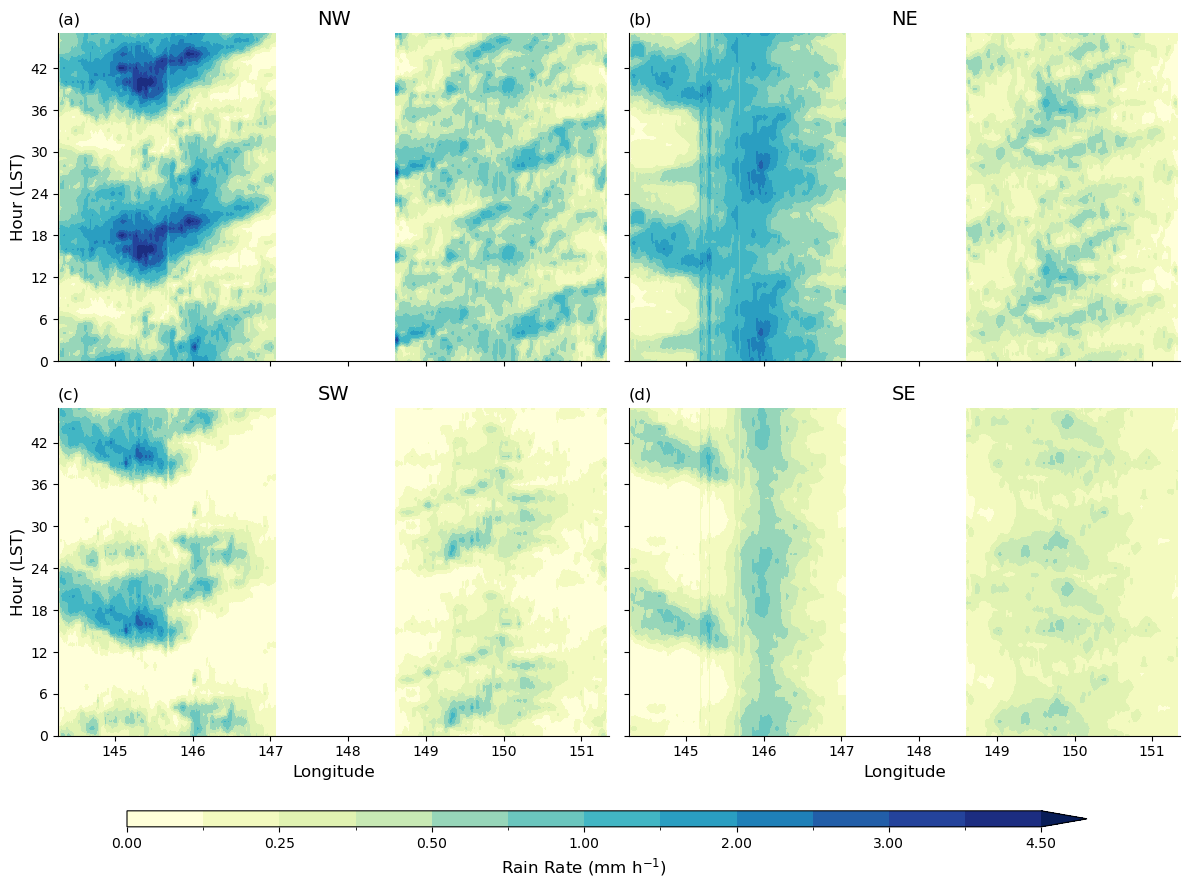

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True, sharex=True)
fig.patch.set_facecolor('white')

regimes   = ['nw', 'ne', 'sw', 'se']
titles    = {'nw': 'NW', 'ne': 'NE', 'sw': 'SW', 'se': 'SE'}
labels    = {'nw': '(a)', 'ne': '(b)', 'sw': '(c)', 'se': '(d)'}
levels_rr = [0, 0.125, 0.25, 0.375, 0.5, 0.75, 1, 1.5, 2, 2.5, 3, 3.5, 4.5]
cmap_rr   = 'YlGnBu'
norm_rr   = matplotlib.colors.BoundaryNorm(levels_rr, plt.cm.YlGnBu.N, extend='max')

for ax, regime in zip(axes.flat, regimes):
    # --- Cairns ---
    da_c = results['cairns'][regime].rainrate.compute()
    hours_48  = np.concatenate([da_c.hour.values, da_c.hour.values + 24])
    rain_48_c = np.concatenate([da_c.values, da_c.values], axis=0)
    im = ax.contourf(da_c.lon.values, hours_48, rain_48_c,
                     levels=levels_rr, cmap=cmap_rr, norm=norm_rr)

    # --- Willis ---
    da_w = results['willis'][regime].rainrate.compute()
    hours_48_w  = np.concatenate([da_w.hour.values, da_w.hour.values + 24])
    rain_48_w   = np.concatenate([da_w.values, da_w.values], axis=0)
    ax.contourf(da_w.lon.values, hours_48_w, rain_48_w,
                levels=levels_rr, cmap=cmap_rr, norm=norm_rr)

    # ax.axvline(145.9, color='black', linestyle='--', linewidth=0.8, alpha=0.7)  # Cairns radar
    # ax.axvline(149.5, color='grey',  linestyle='--', linewidth=0.8, alpha=0.7)  # Willis radar
    ax.set_title(titles[regime], fontsize=14)
    ax.set_title(labels[regime], loc='left', fontsize=12)
    ax.set_yticks(np.arange(0, 48, 6))
    ax.spines[['top', 'right']].set_visible(False)

axes[1, 0].set_xlabel('Longitude', fontsize=12)
axes[1, 1].set_xlabel('Longitude', fontsize=12)
axes[0, 0].set_ylabel('Hour (LST)', fontsize=12)
axes[1, 0].set_ylabel('Hour (LST)', fontsize=12)

cax  = fig.add_axes([0.11, -0.04, 0.8, 0.02])
sm   = plt.cm.ScalarMappable(norm=norm_rr, cmap=cmap_rr)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', extend='max')
cbar.set_label(r'Rain Rate (mm h$^{-1}$)', fontsize=12)

plt.tight_layout()
plt.show()

# Load and select satellite data

In [8]:
def him8_files(directory):
    file_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith("_ch13BT_regridded_2kmres.nc"):  
                file_paths.append(os.path.join(root, file))
    return file_paths
directory = "/g/data/q90/ac9768/GBR/him8"
files = him8_files(directory)

In [9]:
def utc_to_lst_shift(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    ds_lst = ds.assign_coords(time=ds.time + offset)
    return ds_lst

In [10]:
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw


# --- Usage ---
lon_towns  = (145.12054 + 147.9812)  / 2  # ≈ 146.55°E
lon_cairns = (144.27374 + 147.09222) / 2  # ≈ 145.68°E
lon_willis = (148.55927 + 151.36993) / 2

ds_barra = xr.open_mfdataset('/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa_winds_cairns.nc',engine="netcdf4")
ds_barra = ds_barra.sortby('time')
ds_selected = ds_barra.sel(time=slice('2016-01-01', '2020-04-01'))
barra = ds_selected.sel(time=~(ds_selected['time.month'] == 4))
ne, se, sw, nw = wind_times(barra, lon_cairns)

In [11]:
def read_netcdf_him8(file_path,wind_times):
    with xr.open_mfdataset(file_path,engine="h5netcdf", chunks="auto") as ds:
        barra_winds = ds.ch13BT.sel(time=wind_times,method="nearest").sel(lat=slice(-17,-16.6)) 
        result_mean = barra_winds.groupby(barra_winds.time.dt.hour).mean(dim=["lat","time"]) 
    return result_mean 

In [12]:
ne_him_mean = read_netcdf_him8(files,ne)
se_him_mean = read_netcdf_him8(files,se)
sw_him_mean = read_netcdf_him8(files,sw)
nw_him_mean = read_netcdf_him8(files,nw)

In [13]:
ne_result_mean = ne_him_mean.compute()
se_result_mean = se_him_mean.compute()
sw_result_mean = sw_him_mean.compute()
nw_result_mean = nw_him_mean.compute()

In [14]:
def utc_to_lst_shift_him8(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)  # degrees → minutes → hours
    # Shift data values along the time axis (dask-safe, no compute triggered)
    ds_shifted = ds.roll(hour=offset_hours, roll_coords=True)
    return ds_shifted

In [15]:
ne_bt_mean_aedt = utc_to_lst_shift_him8(ne_result_mean,lon_cairns)
se_bt_mean_aedt = utc_to_lst_shift_him8(se_result_mean,lon_cairns)
sw_bt_mean_aedt = utc_to_lst_shift_him8(sw_result_mean,lon_cairns)
nw_bt_mean_aedt = utc_to_lst_shift_him8(nw_result_mean,lon_cairns)

In [16]:
bt_long = xr.open_dataset('/g/data/q90/ac9768/GBR/him8/2020_ch13BT_regridded_2kmres.nc', engine="h5netcdf", chunks="auto")
bt_lon = bt_long.lon.load().values

# Plot satellite and radar

In [17]:
# double all arrays to plot between 48 hours
def double_array(arr):
    return np.concatenate([arr, arr])

ne_double_him_mean = double_array(ne_bt_mean_aedt)
se_double_him_mean = double_array(se_bt_mean_aedt)
sw_double_him_mean = double_array(sw_bt_mean_aedt)
nw_double_him_mean = double_array(nw_bt_mean_aedt)

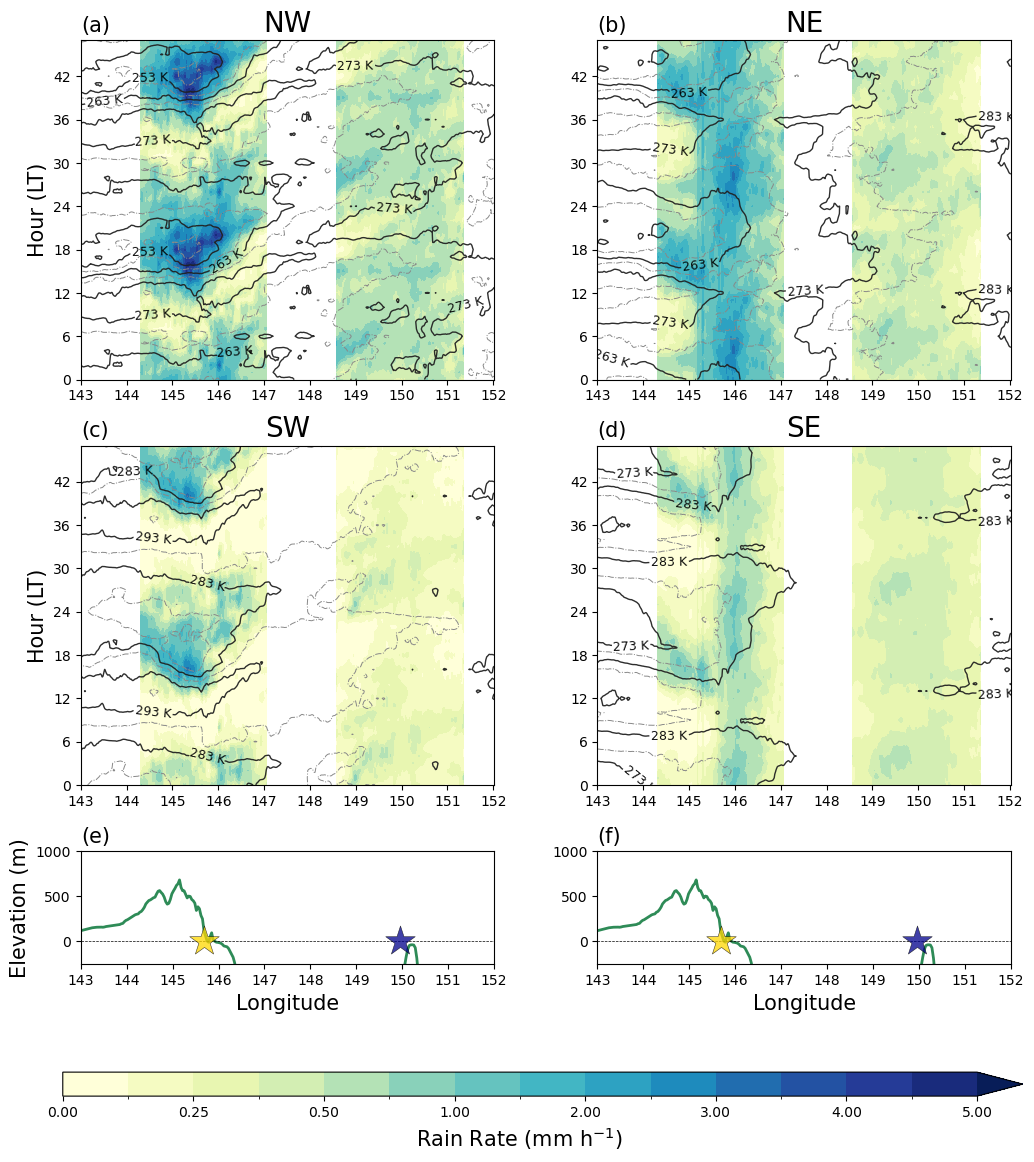

In [69]:
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(12, 12))
fig.patch.set_facecolor('white')

gs = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[3, 3, 1], hspace=0.25, wspace=0.25)
# gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[3, 3], hspace=0.25, wspace=0.35)

ax = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])
ax_bot = [fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])]

# plot data
levels_h8 = np.arange(241, 305, 2.5)
levels_rr = [0, 0.125, 0.25, 0.375, 0.5, 0.75, 1, 1.5, 2,2.5,3,3.5,4,4.5,5]
alpha_rr  = 1#0.75
light_grey = '#888888'
dark_grey  = '#222222'

cmap_h8 = matplotlib.cm.binary
cmap_rr = matplotlib.cm.YlGnBu
norm    = matplotlib.colors.BoundaryNorm(levels_h8, cmap_h8.N, extend='both')
norm_rr = matplotlib.colors.BoundaryNorm(levels_rr, cmap_rr.N, extend='max')

# x values for BT
bt_long = xr.open_dataset('/g/data/q90/ac9768/GBR/him8/2020_ch13BT_regridded_2kmres.nc', engine="h5netcdf", chunks="auto")
bt_lon  = bt_long.lon.values
time    = np.arange(0, 48, 1)

# topography
# --- bottom row ---
ds_full = xr.open_dataset('/home/563/ac9768/GBR/Aus_Bathymetry/ETOPO2v2c_f4.GQp62nWv.nc.part', engine="netcdf4")
ds_bath = ds_full.sel(x=slice(143, 152), y=slice(-22, -11))
bath_mean = ds_bath['z'].sel(y=slice(-16.993225, -16.633728)).mean(dim='y')
long = ds_bath.sel(y=-16.8, method='nearest').drop_vars('z')

# regime order matching ax layout: [0,0]=NW, [0,1]=NE, [1,0]=SW, [1,1]=SE
regime_ax_map = [
    (ax[0, 0], 'nw', nw_double_him_mean, '(a)', 'NW'),
    (ax[0, 1], 'ne', ne_double_him_mean, '(b)', 'NE'),
    (ax[1, 0], 'sw', sw_double_him_mean, '(c)', 'SW'),
    (ax[1, 1], 'se', se_double_him_mean, '(d)', 'SE'),
]

for a, regime, him_mean, label, title in regime_ax_map:
   # --- BT contours -------------------------------------------------
    levels = np.arange(243, 308, 10)        # 243, 253, 263 ... 303  (labeled)
    halflevels = np.arange(248, 313, 10)    # 248, 258, 268 ... 308  (unlabeled)
    
    # Solid labeled contours every 10 K
    cs = a.contour(bt_lon, time, him_mean, levels=levels,
                   colors=dark_grey, linewidths=1, linestyles='-',alpha=0.95)
    a.clabel(cs, fmt='%d K', colors='black', fontsize=9,
             inline=True, inline_spacing=2)
    
    # Dashed unlabeled contours at the halfway points
    a.contour(bt_lon, time, him_mean, levels=halflevels,
              colors=light_grey, linewidths=0.7, linestyles='-.')
    
    # --- Cairns radar -------------------------------------------------
    da_c      = results['cairns'][regime].rainrate.compute()
    hours_48  = np.concatenate([da_c.hour.values, da_c.hour.values + 24])
    rain_48_c = np.concatenate([da_c.values, da_c.values], axis=0)
    a.contourf(da_c.lon.values, hours_48, rain_48_c,
               levels=levels_rr, cmap=cmap_rr, norm=norm_rr, alpha=alpha_rr)

    # --- Willis radar -------------------------------------------------
    da_w      = results['willis'][regime].rainrate.compute()
    hours_48_w = np.concatenate([da_w.hour.values, da_w.hour.values + 24])
    rain_48_w  = np.concatenate([da_w.values, da_w.values], axis=0)
    a.contourf(da_w.lon.values, hours_48_w, rain_48_w,
               levels=levels_rr, cmap=cmap_rr, norm=norm_rr, alpha=alpha_rr)

    # # --- Topography -------------------------------------------------
    # ax_topo = a.twinx()
    # bath_mean = ds_bath['z'].sel(y=slice(-17, -16.6)).mean(dim='y')
    # long = ds_bath.sel(y=-16.8, method='nearest').drop_vars('z')
    
    # topo_land = bath_mean.where(bath_mean > 0)
    # ax_topo.fill_between(
    #     long.x,
    #     0,                          # surface
    #     topo_land,                        # top of terrain in pressure coords
    #     color='black',#'saddlebrown',
    #     alpha=0.5,
    #     zorder=5,
    #     ec='white'
    # )
    # ax_topo.set_ylim(0,5000)
    # ax_topo.set_yticks([0,500,1000])
    # ax_topo.set_ylabel("Elevation (m)", fontsize=15,loc='bottom')
    # lon_cairns_site = 145.683
    # lon_willis_site = 149.96 
    # a.scatter(lon_cairns_site, 0, marker='o', color='gold', s=150,alpha=1,
    #           zorder=7, edgecolors='black', linewidths=0.4, label='Cairns radar',clip_on=False)
    # a.scatter(lon_willis_site, 0, marker='o', color='darkblue', s=150,alpha=1,
    #           zorder=7, edgecolors='black', linewidths=0.4, label='Willis radar',clip_on=False)

    # --- Labels -------------------------------------------------
    a.set_title(title, fontsize=20)
    a.set_title(label, loc='left', fontsize=15)
    a.set_yticks(np.arange(0, 48, 6))
    a.set_xticks(np.arange(143,153,1))

# --- Topography -------------------------------------------------
lon_cairns_site = 145.683
lon_willis_site = 149.96

for a in ax_bot:
    a.plot(long.x, bath_mean, color='seagreen', linewidth=2)
    a.axhline(0, color='black', alpha=1, linestyle='--', linewidth=0.5)
    a.set_xlabel("Longitude", fontsize=15)
    a.set_ylim(-250, 1000)
    a.set_xlim(143, 152)
    a.scatter(lon_cairns_site, 0, marker='*', color='gold', s=500,alpha=0.75,
              zorder=5, edgecolors='black', linewidths=0.4, label='Cairns radar')
    a.scatter(lon_willis_site, 0, marker='*', color='darkblue', s=500,alpha=0.75,
              zorder=5, edgecolors='black', linewidths=0.4, label='Willis radar')
ax_bot[0].set_title('(e)', loc='left', fontsize=15)
ax_bot[1].set_title('(f)', loc='left', fontsize=15)

ax_bot[0].set_ylabel("Elevation (m)", fontsize=15)

# --- colorbars ---
dax = fig.add_axes([0.11, -0.0, 0.8, 0.02])
# dax = fig.add_axes([0.11, 0.025, 0.8, 0.02])
sm_rr = plt.cm.ScalarMappable(norm=norm_rr, cmap=cmap_rr)
sm_rr.set_array([])
cbar_rr = fig.colorbar(sm_rr, cax=dax, orientation='horizontal', alpha=alpha_rr)
cbar_rr.set_label(r'Rain Rate (mm h$^{-1}$)', fontsize=15)

# --- axis labels ---
ax[0, 0].set_ylabel("Hour (LT)", fontsize=15)
ax[1, 0].set_ylabel("Hour (LT)", fontsize=15)

plt.show()
fig.savefig('/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/f07.png',bbox_inches='tight',dpi=300)

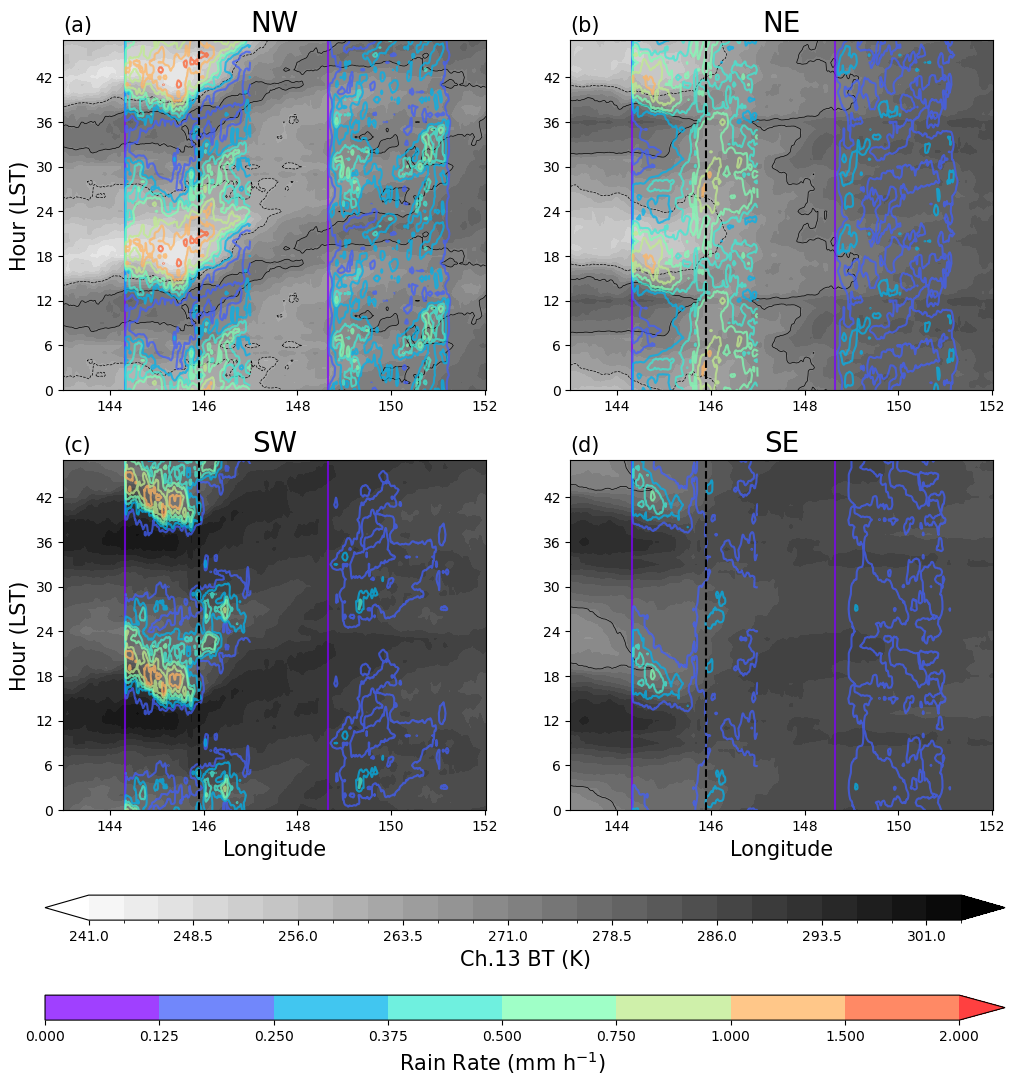

In [26]:
# figure without orography
# setup figure
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(2,2,figsize=(12,10))
fig.patch.set_facecolor('white')

# plot data
levels_h8 = np.arange(241,305,2.5)
levels_rr = np.arange(0,2,0.1)
levels_rr = [0,0.125,0.25,0.375,0.5,0.75,1,1.5,2]
alpha_rr = 0.75

# levels_rr = np.logspace(np.log10(0.01), np.log10(2.25), num=8)
cmap_h8 = matplotlib.cm.binary
cmap_rr = matplotlib.cm.rainbow # YlGnBu
norm = matplotlib.colors.BoundaryNorm(levels_h8, cmap_h8.N, extend='both')
norm_rr = matplotlib.colors.BoundaryNorm(levels_rr, cmap_rr.N,extend='max')  # , extend='max' if needed
# norm_rr = LogNorm(vmin=levels_rr[0], vmax=levels_rr[-1])

# x values
bt_long = xr.open_dataset('/g/data/q90/ac9768/GBR/him8/2020_ch13BT_regridded_2kmres.nc', engine="h5netcdf", chunks="auto")
bt_lon = bt_long.lon.values
x_cairns = xr.open_dataset(cairns_radar_files[0]).longitude.sel(x=slice(-150000,140000)).mean('y').values
x_willis = xr.open_dataset(willis_radar_files[0]).longitude.sel(x=slice(-150000,140000)).mean('y').values

# y values
time = np.arange(0,48,1)

# z values
ax[0,1].contourf(bt_lon,time,ne_double_him_mean,levels=levels_h8,cmap=cmap_h8,alpha=1)
ax[0,1].contour(bt_lon,time,ne_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[0,1].contour(bt_lon,time,ne_double_him_mean,levels=[263],colors="black",alpha=1,linewidths=0.5,linestyles='--')
ax[0,1].contour(x_cairns,time,results['cairns']['ne'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)
ax[0,1].contour(x_willis,time,results['willis']['ne'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)

ax[1,1].contourf(bt_lon,time,se_double_him_mean,levels=levels_h8,cmap=cmap_h8,alpha=1)
ax[1,1].contour(bt_lon,time,se_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[1,1].contour(x_cairns,time,results['cairns']['se'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)
ax[1,1].contour(x_willis,time,results['willis']['se'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)

ax[1,0].contourf(bt_lon,time,sw_double_him_mean,levels=levels_h8,cmap=cmap_h8,alpha=1)
ax[1,0].contour(bt_lon,time,sw_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[1,0].contour(x_cairns,time,results['cairns']['sw'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)
ax[1,0].contour(x_willis,time,results['willis']['sw'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)

ax[0,0].contourf(bt_lon,time,nw_double_him_mean,levels=levels_h8,cmap=cmap_h8,alpha=1)
ax[0,0].contour(bt_lon,time,nw_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[0,0].contour(bt_lon,time,nw_double_him_mean,levels=[263],colors="black",alpha=1,linewidths=0.5,linestyles='--')
ax[0,0].contour(x_cairns,time,results['cairns']['nw'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)
ax[0,0].contour(x_willis,time,results['willis']['nw'],levels=levels_rr,cmap=cmap_rr,alpha=alpha_rr,norm=norm_rr)

# colorbars
cax = fig.add_axes([0.11, 0, 0.8, 0.025])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_h8)
sm.set_array([])  # Empty array since data is already in the norm
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label(label='Ch.13 BT (K)', fontsize=15)

dax = fig.add_axes([0.11, -0.1, 0.8, 0.025])  # [left, bottom, width, height]
norm_rr = matplotlib.colors.BoundaryNorm(levels_rr, cmap_rr.N,extend='max')  # , extend='max' if needed
sm_rr = plt.cm.ScalarMappable(norm=norm_rr, cmap=cmap_rr)
sm_rr.set_array([])
cbar_rr = fig.colorbar(sm_rr, cax=dax, orientation='horizontal',alpha=alpha_rr)
cbar_rr.set_label(r'Rain Rate (mm h$^{-1}$)', fontsize=15)

# other plot details
ax[1,1].set_xlabel("Longitude",fontsize=15)
ax[1,0].set_xlabel("Longitude",fontsize=15)
ax[1,0].set_ylabel("Hour (LST)",fontsize=15)
ax[0,0].set_ylabel("Hour (LST)",fontsize=15)

ax[0,1].set_title("NE",fontsize=20)
ax[0, 1].set_title("(b)", loc="left", fontsize=15)

ax[1,1].set_title("SE",fontsize=20)
ax[1, 1].set_title("(d)", loc="left", fontsize=15)

ax[1,0].set_title("SW",fontsize=20)
ax[1, 0].set_title("(c)", loc="left", fontsize=15)

ax[0,0].set_title("NW",fontsize=20)
ax[0, 0].set_title("(a)", loc="left", fontsize=15)

for ax in ax.flat:
    ax.set_yticks(np.arange(0,48,6))
    ax.axvline(145.9,color='black',alpha=1,linestyle='--')
    # ax.grid(linestyle='--',alpha=0.5)
fig.savefig('/home/563/ac9768/GBR/scripts/Paper_figures/f07_ref-radar.png',bbox_inches='tight',dpi=300)

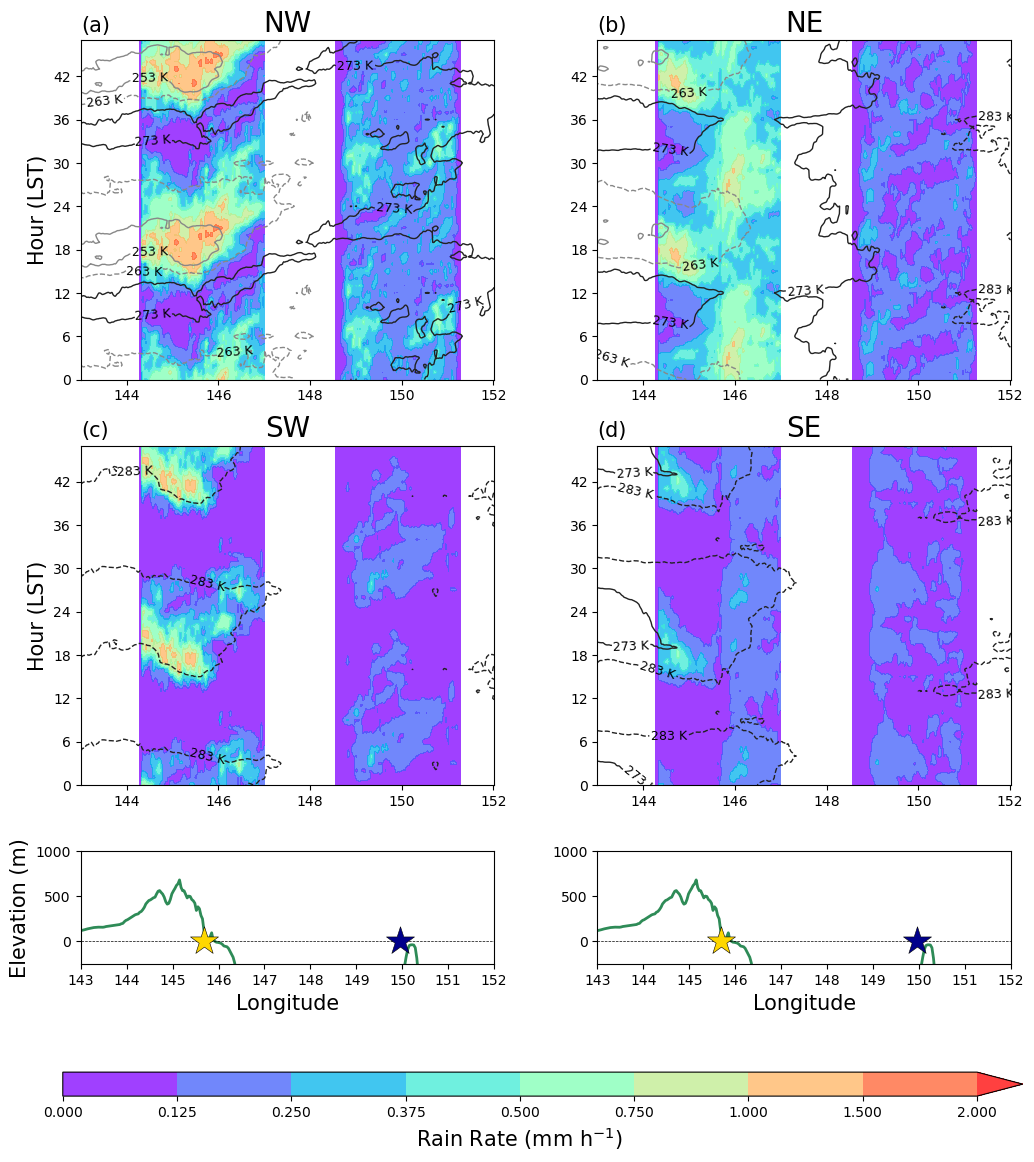

In [64]:
# add topography as subpanels below - 

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(12, 12))
fig.patch.set_facecolor('white')

# 3 rows: 2 main (equal height) + 1 narrow (1/3 height)
gs = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[3, 3, 1], hspace=0.25, wspace=0.25)

ax = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])
ax_bot = [fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])]

# plot data
levels_h8 = np.arange(241, 305, 2.5)
levels_rr = [0, 0.125, 0.25, 0.375, 0.5, 0.75, 1, 1.5, 2]
alpha_rr = 0.75

cmap_h8 = matplotlib.cm.binary
cmap_rr = matplotlib.cm.rainbow
norm    = matplotlib.colors.BoundaryNorm(levels_h8, cmap_h8.N, extend='both')
norm_rr = matplotlib.colors.BoundaryNorm(levels_rr, cmap_rr.N, extend='max')

# x values
bt_long = xr.open_dataset('/g/data/q90/ac9768/GBR/him8/2020_ch13BT_regridded_2kmres.nc', engine="h5netcdf", chunks="auto")
bt_lon  = bt_long.lon.values
x_cairns = xr.open_dataset(cairns_radar_files[0]).longitude.sel(x=slice(-150000, 140000)).mean('y').values
x_willis = xr.open_dataset(willis_radar_files[0]).longitude.sel(x=slice(-150000, 140000)).mean('y').values

time = np.arange(0, 48, 1)

# --- main 4-panel plots (unchanged) ---
# ax[0,1].contourf(bt_lon, time, ne_double_him_mean, levels=levels_h8, cmap=cmap_h8, alpha=1)
ax[0,1].contourf(x_cairns, time, results['cairns']['ne'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)
ax[0,1].contourf(x_willis, time, results['willis']['ne'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)

# ax[1,1].contourf(bt_lon, time, se_double_him_mean, levels=levels_h8, cmap=cmap_h8, alpha=1)
ax[1,1].contourf(x_cairns, time, results['cairns']['se'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)
ax[1,1].contourf(x_willis, time, results['willis']['se'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)

# ax[1,0].contourf(bt_lon, time, sw_double_him_mean, levels=levels_h8, cmap=cmap_h8, alpha=1)
ax[1,0].contourf(x_cairns, time, results['cairns']['sw'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)
ax[1,0].contourf(x_willis, time, results['willis']['sw'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)

# ax[0,0].contourf(bt_lon, time, nw_double_him_mean, levels=levels_h8, cmap=cmap_h8, alpha=1)
ax[0,0].contourf(x_cairns, time, results['cairns']['nw'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)
ax[0,0].contourf(x_willis, time, results['willis']['nw'], levels=levels_rr, cmap=cmap_rr, alpha=alpha_rr, norm=norm_rr)

for a, him_mean in zip(ax.flat, [nw_double_him_mean, ne_double_him_mean, sw_double_him_mean, se_double_him_mean]):
    c253 = a.contour(bt_lon, time, him_mean, levels=[253], colors='#888888', linewidths=1, linestyles='-')
    c263 = a.contour(bt_lon, time, him_mean, levels=[263], colors='#888888', linewidths=1, linestyles='--')
    c273 = a.contour(bt_lon, time, him_mean, levels=[273], colors='#222222',  linewidths=1, linestyles='-')
    c283 = a.contour(bt_lon, time, him_mean, levels=[283], colors='#222222',  linewidths=1, linestyles='--')

    for c, label in zip([c253, c263, c273, c283], ['253 K', '263 K', '273 K', '283 K']):
        a.clabel(c, fmt={c.levels[0]: label}, colors='black',fontsize=9, inline=True, inline_spacing=2)

# --- bottom row (1/3 height) — 
ds_full = xr.open_dataset('/home/563/ac9768/GBR/Aus_Bathymetry/ETOPO2v2c_f4.GQp62nWv.nc.part',engine="netcdf4")
ds_bath = ds_full.sel(x=slice(140,155),y=slice(-22,-11))

long=ds_bath.sel(y=-16.8,method='nearest').drop_vars('z')
ax_bot[0].plot(long.x,ds_bath['z'].sel(y=slice(-16.993225,-16.633728)).mean(dim='y'),color='seagreen',linewidth=2)
ax_bot[1].plot(long.x,ds_bath['z'].sel(y=slice(-16.993225,-16.633728)).mean(dim='y'),color='seagreen',linewidth=2)
ax_bot[0].set_ylabel("Elevation (m)",fontsize=15)

lon_cairns_site = 145.683  
lon_willis_site = 149.96

for a in ax_bot:
    a.axhline(-0, color='black', alpha=1, linestyle='--',linewidth=0.5)
    a.set_xlabel("Longitude",fontsize=15)
    a.set_ylim(-250,1000)
    a.set_xlim(143,152)
    a.scatter(lon_cairns_site, 0, marker='*', color='gold', s=450,
              zorder=5, edgecolors='black', linewidths=0.4, label='Radar site')
    a.scatter(lon_willis_site, 0, marker='*', color='darkblue', s=450,
              zorder=5, edgecolors='black', linewidths=0.4)

# --- colorbars ---
# cax = fig.add_axes([0.11, 0.0, 0.8, 0.02])
# sm  = plt.cm.ScalarMappable(norm=norm, cmap=cmap_h8)
# sm.set_array([])
# cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
# cbar.set_label('Ch.13 BT (K)', fontsize=15)
# bt_legend_elements = [
#     Line2D([0], [0], color='#888888', linewidth=2, linestyle='-', label='253 K'),
#     Line2D([0], [0], color='#888888', linewidth=2, linestyle='--', label='263 K'),
#     Line2D([0], [0], color='#222222', linewidth=2, linestyle='-',  label='273 K'),
#     Line2D([0], [0], color='#222222', linewidth=2, linestyle='--',  label='283 K'),
# ]

# fig.legend(
#     handles=bt_legend_elements,
#     title='Ch.13 BT',
#     loc='lower center',
#     bbox_to_anchor=(0.5, -0.02),
#     ncol=4,
#     frameon=True,
#     fontsize=14,
#     title_fontsize=15,
# )
dax = fig.add_axes([0.11, -0.0, 0.8, 0.02])# if legend =-0.08
sm_rr = plt.cm.ScalarMappable(norm=norm_rr, cmap=cmap_rr)
sm_rr.set_array([])
cbar_rr = fig.colorbar(sm_rr, cax=dax, orientation='horizontal', alpha=alpha_rr)
cbar_rr.set_label(r'Rain Rate (mm h$^{-1}$)', fontsize=15)

# --- labels and titles ---
# ax[1,1].set_xlabel("Longitude", fontsize=15)
# ax[1,0].set_xlabel("Longitude", fontsize=15)
ax[1,0].set_ylabel("Hour (LST)", fontsize=15)
ax[0,0].set_ylabel("Hour (LST)", fontsize=15)

ax[0,1].set_title("NE", fontsize=20)
ax[0,1].set_title("(b)", loc="left", fontsize=15)
ax[1,1].set_title("SE", fontsize=20)
ax[1,1].set_title("(d)", loc="left", fontsize=15)
ax[1,0].set_title("SW", fontsize=20)
ax[1,0].set_title("(c)", loc="left", fontsize=15)
ax[0,0].set_title("NW", fontsize=20)
ax[0,0].set_title("(a)", loc="left", fontsize=15)

for a in ax.flat:
    a.set_yticks(np.arange(0, 48, 6))
    # a.axvline(145.9, color='black', alpha=1, linestyle='--')

fig.savefig('/home/563/ac9768/GBR/scripts/Paper_figures/f07_ref-radar-topog-formatchanges-inlinev4.png',bbox_inches='tight',dpi=300)

In [29]:
bt_long

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 2167, lat: 446, lon: 502)
Coordinates:
  * time     (time) datetime64[ns] 17kB 2020-01-01 ... 2020-03-31T23:00:00
  * lat      (lat) float64 4kB -22.0 -21.98 -21.96 ... -14.03 -14.01 -13.99
  * lon      (lon) float64 4kB 143.0 143.0 143.0 143.1 ... 152.0 152.0 152.0
Data variables:
    ch13BT   (time, lat, lon) float32 2GB dask.array<chunksize=(149, 446, 502), meta=np.ndarray>
Attributes:
    note:     2017 JFM ch13BT with smaller domain ~11km spatial resolution, f...

# adding topography on contours

In [47]:
# open topography dataset
ds_full = xr.open_dataset('/home/563/ac9768/GBR/Aus_Bathymetry/ETOPO2v2c_f4.GQp62nWv.nc.part',engine="netcdf4")
ds_bath = ds_full.sel(x=slice(140,155),y=slice(-22,-11))

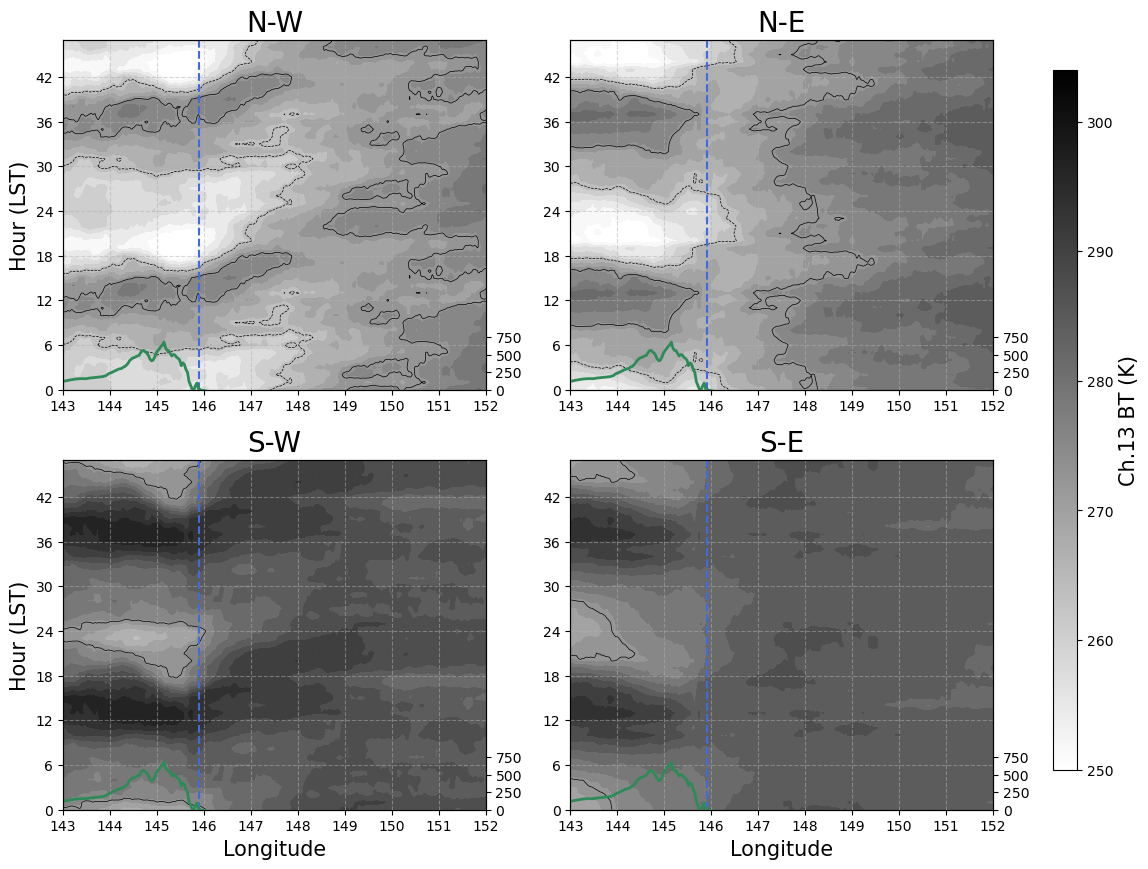

In [52]:
# topo
fig, ax = plt.subplots(2,2,figsize=(12,10))
fig.patch.set_facecolor('white')
levels=np.arange(250,305,3)
ax[0,1].contourf(bt_lon,np.arange(0,48,1),ne_double_him_mean,levels=levels,cmap="binary",alpha=1)
ax[0,1].contour(bt_lon,np.arange(0,48,1),ne_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[0,1].contour(bt_lon,np.arange(0,48,1),ne_double_him_mean,levels=[263],colors="black",alpha=1,linewidths=0.5,linestyles='--')
ax[1,1].contourf(bt_lon,np.arange(0,48,1),se_double_him_mean,levels=levels,cmap="binary",alpha=1)
ax[1,1].contour(bt_lon,np.arange(0,48,1),se_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[1,0].contourf(bt_lon,np.arange(0,48,1),sw_double_him_mean,levels=levels,cmap="binary",alpha=1)
ax[1,0].contour(bt_lon,np.arange(0,48,1),sw_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[0,0].contourf(bt_lon,np.arange(0,48,1),nw_double_him_mean,levels=levels,cmap="binary",alpha=1)
ax[0,0].contour(bt_lon,np.arange(0,48,1),nw_double_him_mean,levels=[273],colors="black",alpha=1,linewidths=0.5)
ax[0,0].contour(bt_lon,np.arange(0,48,1),nw_double_him_mean,levels=[263],colors="black",alpha=1,linewidths=0.5,linestyles='--')

cax = fig.add_axes([0.95, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
# # Create a colorbar using the ScalarMappable from one of the subplots
sm = plt.cm.ScalarMappable(cmap="binary")
sm.set_array(levels)  # You need to set an array for the ScalarMappable
cbar = plt.colorbar(sm,cax=cax)
cbar.set_label(label='Ch.13 BT (K)',fontsize=15)

# plot topography
# make twin axis for topography overlay
ax1 = ax[0,0].twinx()
ax1.set_ylim(0,5000)
ax1.set_yticks(np.arange(0,1000,250))
ax1.set_xlim(143,152)
ax2 = ax[0,1].twinx()
ax2.set_ylim(0,5000)
ax2.set_yticks(np.arange(0,1000,250))
ax2.set_xlim(143,152)
ax3 = ax[1,0].twinx()
ax3.set_ylim(0,5000)
ax3.set_yticks(np.arange(0,1000,250))
ax3.set_xlim(143,152)
ax4 = ax[1,1].twinx()
ax4.set_ylim(0,5000)
ax4.set_yticks(np.arange(0,1000,250))
ax4.set_xlim(143,152)
long=ds_bath.sel(y=-16.8,method='nearest').drop_vars('z')
ax1.plot(long.x,ds_bath['z'].sel(y=slice(-16.993225,-16.633728)).mean(dim='y'),color='seagreen',linewidth=2)
# ax1.plot(long.x,ds_bath['z'].sel(y=-16.8,method='nearest'),color='seagreen',linewidth=2)
ax2.plot(long.x,ds_bath['z'].sel(y=slice(-16.993225,-16.633728)).mean(dim='y'),color='seagreen',linewidth=2)
ax3.plot(long.x,ds_bath['z'].sel(y=slice(-16.993225,-16.633728)).mean(dim='y'),color='seagreen',linewidth=2)
ax4.plot(long.x,ds_bath['z'].sel(y=slice(-16.993225,-16.633728)).mean(dim='y'),color='seagreen',linewidth=2)

ax[1,1].set_xlabel("Longitude",fontsize=15)
ax[1,0].set_xlabel("Longitude",fontsize=15)
ax[1,0].set_ylabel("Hour (LST)",fontsize=15)
ax[0,0].set_ylabel("Hour (LST)",fontsize=15)
ax[0,0].set_yticks(np.arange(0,48,6))
ax[0,1].set_yticks(np.arange(0,48,6))
ax[1,0].set_yticks(np.arange(0,48,6))
ax[1,1].set_yticks(np.arange(0,48,6))
ax[0,1].set_title("N-E",fontsize=20)
ax[1,1].set_title("S-E",fontsize=20)
ax[1,0].set_title("S-W",fontsize=20)
ax[0,0].set_title("N-W",fontsize=20)
ax[0,1].axvline(145.9,color='royalblue',alpha=1,linestyle='--')
ax[1,1].axvline(145.9,color='royalblue',alpha=1,linestyle='--')
ax[1,0].axvline(145.9,color='royalblue',alpha=1,linestyle='--')
ax[0,0].axvline(145.9,color='royalblue',alpha=1,linestyle='--')
ax[0,1].grid(linestyle='--',alpha=0.5)
ax[1,1].grid(linestyle='--',alpha=0.5)
ax[1,0].grid(linestyle='--',alpha=0.5)
ax[0,0].grid(linestyle='--',alpha=0.5)